<a href="https://colab.research.google.com/github/Aghil-hub/Customer_Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy

In [2]:
df = pd.read_csv('ShopNow Dataset.csv')
df.head()

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,0.031,0.148,0.059,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0
1,2,31,M,High,5,146,171.52,6,5,Home,0.273,0.090,0.476,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0
2,3,43,F,Low,1,546,22.90,1,7,Groceries,0.071,0.008,0.155,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0
3,4,24,M,Low,8,37,38.67,7,4,Home,0.208,0.125,0.272,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0
4,5,29,F,Low,15,71,49.69,13,5,Sports,0.073,0.084,0.205,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0


In [3]:
df.dtypes

,0
customer_id,int64
age,int64
gender,object
income_bucket,object
orders_last_12m,int64
recency_days,int64
avg_order_value,float64
website_visits_30d,int64
email_opens_90d,int64
top_category,object


In [4]:
df.describe()

,customer_id,age,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,purchase_next_30d
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,34.790333,5.29150,199.697667,85.698848,6.501500,5.006000,0.170614,0.168922,0.164107,0.165909,0.165100,0.165338,0.413667,0.225833
std,1732.195139,9.610659,4.07365,221.777102,70.370202,4.767751,2.221738,0.142822,0.142138,0.140662,0.143195,0.139217,0.141137,0.492531,0.418165
min,1.000000,18.000000,0.00000,5.000000,10.620000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1500.750000,28.000000,2.00000,52.000000,33.640000,2.000000,3.000000,0.059000,0.058000,0.056000,0.054000,0.055000,0.055000,0.000000,0.000000
50%,3000.500000,34.500000,5.00000,96.000000,51.420000,6.000000,5.000000,0.133000,0.130000,0.125500,0.126000,0.127000,0.126000,0.000000,0.000000
75%,4500.250000,41.000000,8.00000,310.000000,104.285000,10.000000,6.000000,0.247000,0.244000,0.237000,0.240000,0.243000,0.240000,1.000000,0.000000
max,6000.000000,72.000000,22.00000,799.000000,341.670000,24.000000,15.000000,0.799000,0.813000,0.767000,0.862000,0.824000,0.796000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   int64  
 1   age                    6000 non-null   int64  
 2   gender                 6000 non-null   object 
 3   income_bucket          6000 non-null   object 
 4   orders_last_12m        6000 non-null   int64  
 5   recency_days           6000 non-null   int64  
 6   avg_order_value        6000 non-null   float64
 7   website_visits_30d     6000 non-null   int64  
 8   email_opens_90d        6000 non-null   int64  
 9   top_category           6000 non-null   object 
 10  cat_share_electronics  6000 non-null   float64
 11  cat_share_apparel      6000 non-null   float64
 12  cat_share_home         6000 non-null   float64
 13  cat_share_beauty       6000 non-null   float64
 14  cat_share_groceries    6000 non-null   float64
 15  cat_

orders_last_12m: 


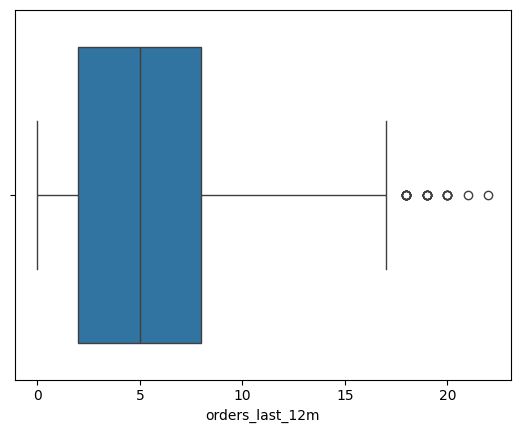

avg_order_value: 


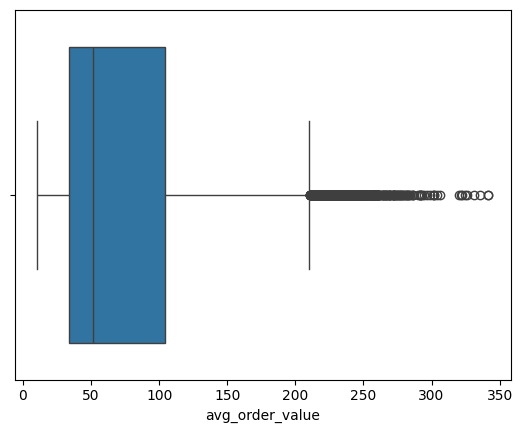

avg_order_value: 


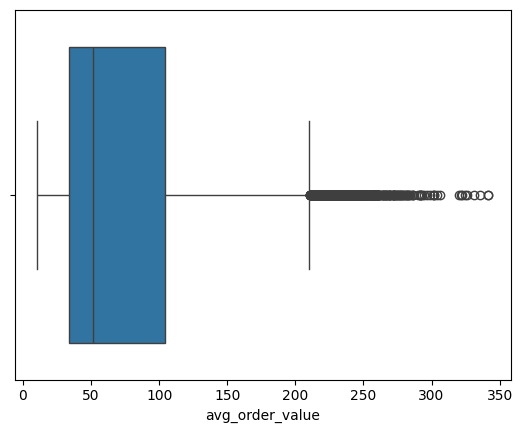

In [6]:
list1 = ['orders_last_12m','avg_order_value','avg_order_value']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=df[str(i)])
    plt.show()

In [7]:
rfm = df[['recency_days','orders_last_12m','avg_order_value']].copy()
rfm.head()

,recency_days,orders_last_12m,avg_order_value
0,185,4,80.41
1,146,5,171.52
2,546,1,22.90
3,37,8,38.67
4,71,15,49.69


In [8]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled

array([[-0.06627777, -0.31706395, -0.07516376],
       [-0.24214466, -0.07156341,  1.21966829],
       [ 1.56161836, -1.05356556, -0.89248119],
       ...,
       [-0.47663386, -0.31706395, -0.15332836],
       [-0.46761504,  1.64694036, -0.72321932],
       [ 2.29214239, -1.05356556, -0.78901969]])

In [9]:
rfm_scaled.mean(axis=0)

array([-5.92118946e-18, -2.25005200e-17,  3.96719694e-17])

In [10]:
rfm_scaled.std(axis=0,ddof=0)

array([1., 1., 1.])

In [11]:
inertia = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

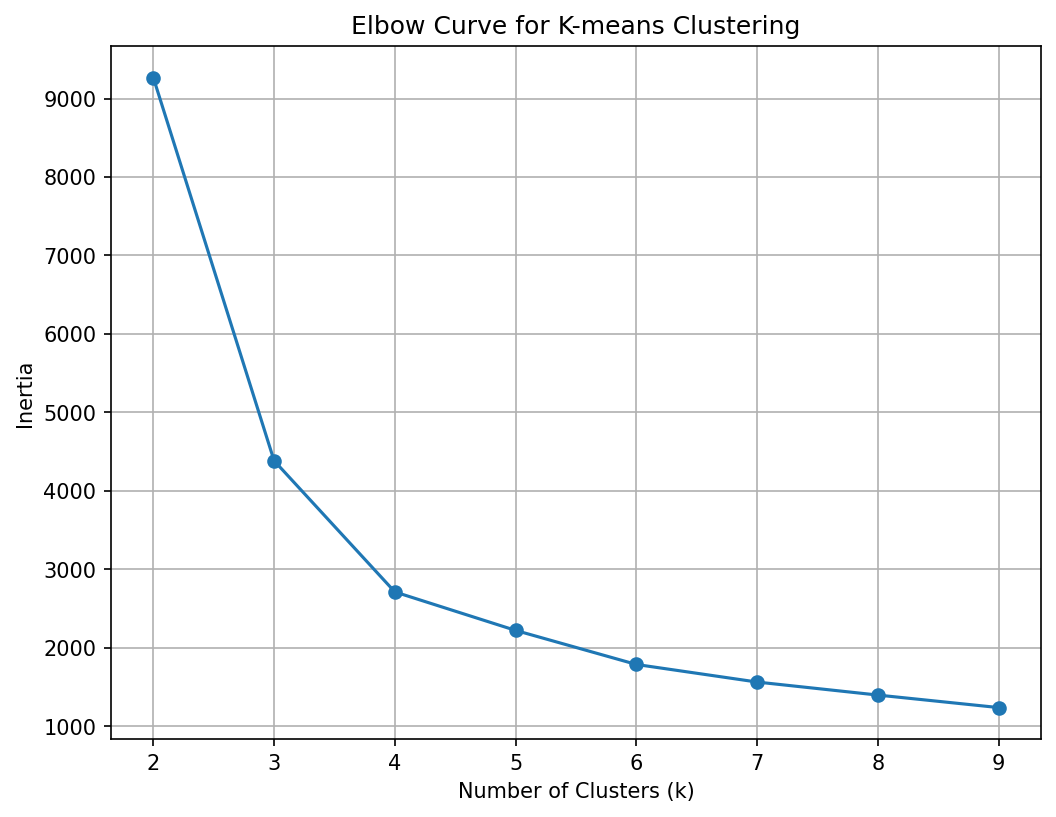

In [12]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [13]:
# Perform K-means clustering with best K
best_kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
rfm['Cluster'] = best_kmeans.fit_predict(rfm_scaled)

In [14]:
# Group by cluster and calculate mean values
cluster_summary = rfm.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean'
}).reset_index()
print(cluster_summary)


   Cluster  recency_days  orders_last_12m  avg_order_value
0        0    549.669271         0.998698        29.900768
1        1     93.260756         5.646905        71.293342
2        2     56.851821        11.627483        45.572922
3        3     79.601481         4.004444       205.428378


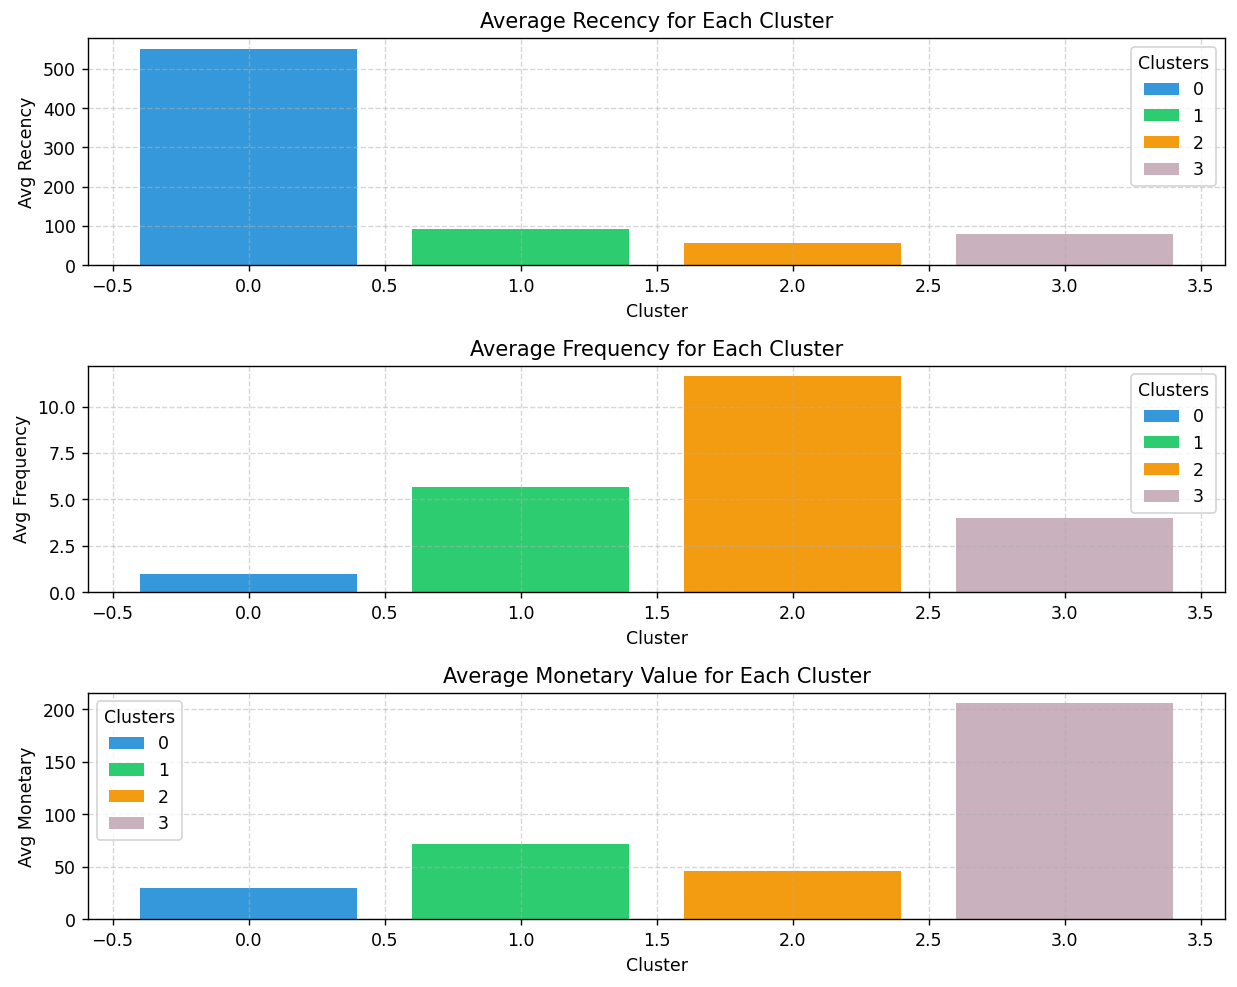

In [15]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 8),dpi=125)

# Plot Avg Recency
plt.subplot(3, 1, 1)
bars = plt.bar(cluster_summary.index, cluster_summary['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(3, 1, 2)
bars = plt.bar(cluster_summary.index, cluster_summary['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(3, 1, 3)
bars = plt.bar(cluster_summary.index, cluster_summary['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

plt.tight_layout()
plt.show()

In [16]:
df.columns

Index(['customer_id', 'age', 'gender', 'income_bucket', 'orders_last_12m',
       'recency_days', 'avg_order_value', 'website_visits_30d',
       'email_opens_90d', 'top_category', 'cat_share_electronics',
       'cat_share_apparel', 'cat_share_home', 'cat_share_beauty',
       'cat_share_groceries', 'cat_share_sports', 'discount_exposed_30d',
       'feedback_text', 'purchase_next_30d'],
      dtype='object')

Creating a new entropy feature by combining category share columns to check whether a customer buys only from a specific category or from all categories.


In [17]:
cat_cols = ["cat_share_electronics","cat_share_apparel","cat_share_home","cat_share_beauty","cat_share_groceries","cat_share_sports"]

def category_entropy(row):
    p = row[cat_cols].values
    p = np.array(p, dtype=np.float64)
    epsilon = 1e-10
    p = p + epsilon
    return entropy(p, base=2)

df["category_entropy"] = df.apply(category_entropy, axis=1)

max_entropy = np.log2(len(cat_cols))
df["category_concentration"] = 1 - df["category_entropy"] / max_entropy

df.head()

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,...,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d,category_entropy,category_concentration
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,...,0.148,0.059,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0,2.261115,0.125281
1,2,31,M,High,5,146,171.52,6,5,Home,...,0.090,0.476,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0,1.996734,0.227558
2,3,43,F,Low,1,546,22.90,1,7,Groceries,...,0.008,0.155,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0,2.013961,0.220894
3,4,24,M,Low,8,37,38.67,7,4,Home,...,0.125,0.272,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0,2.484929,0.038698
4,5,29,F,Low,15,71,49.69,13,5,Sports,...,0.084,0.205,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0,2.203861,0.147430


In [18]:
df[['category_entropy','category_concentration']].describe()

,category_entropy,category_concentration
count,6000.000000,6000.000000
mean,2.089782,0.191562
std,0.252025,0.097497
min,0.828960,0.005328
25%,1.946438,0.119610
50%,2.126282,0.177442
75%,2.275775,0.247015
max,2.571189,0.679315


In [19]:
all_var = df[['recency_days','orders_last_12m','avg_order_value','category_concentration']].copy()
all_var.head()

,recency_days,orders_last_12m,avg_order_value,category_concentration
0,185,4,80.41,0.125281
1,146,5,171.52,0.227558
2,546,1,22.90,0.220894
3,37,8,38.67,0.038698
4,71,15,49.69,0.147430


In [20]:
all_var_scaled = scaler.fit_transform(all_var)
all_var_scaled

array([[-0.06627777, -0.31706395, -0.07516376, -0.67988331],
       [-0.24214466, -0.07156341,  1.21966829,  0.36922992],
       [ 1.56161836, -1.05356556, -0.89248119,  0.30087219],
       ...,
       [-0.47663386, -0.31706395, -0.15332836, -0.37045814],
       [-0.46761504,  1.64694036, -0.72321932, -0.00813083],
       [ 2.29214239, -1.05356556, -0.78901969, -0.93788856]])

In [21]:
all_var_scaled.mean(axis=0)

array([-5.92118946e-18, -2.25005200e-17,  3.96719694e-17, -1.77635684e-17])

In [22]:
all_var_scaled.std(axis=0,ddof=0)

array([1., 1., 1., 1.])

In [23]:
inertia_a = []
for k in range(2,10):
  kmeans_a = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans_a.fit(all_var_scaled)
  inertia_a.append(kmeans_a.inertia_)

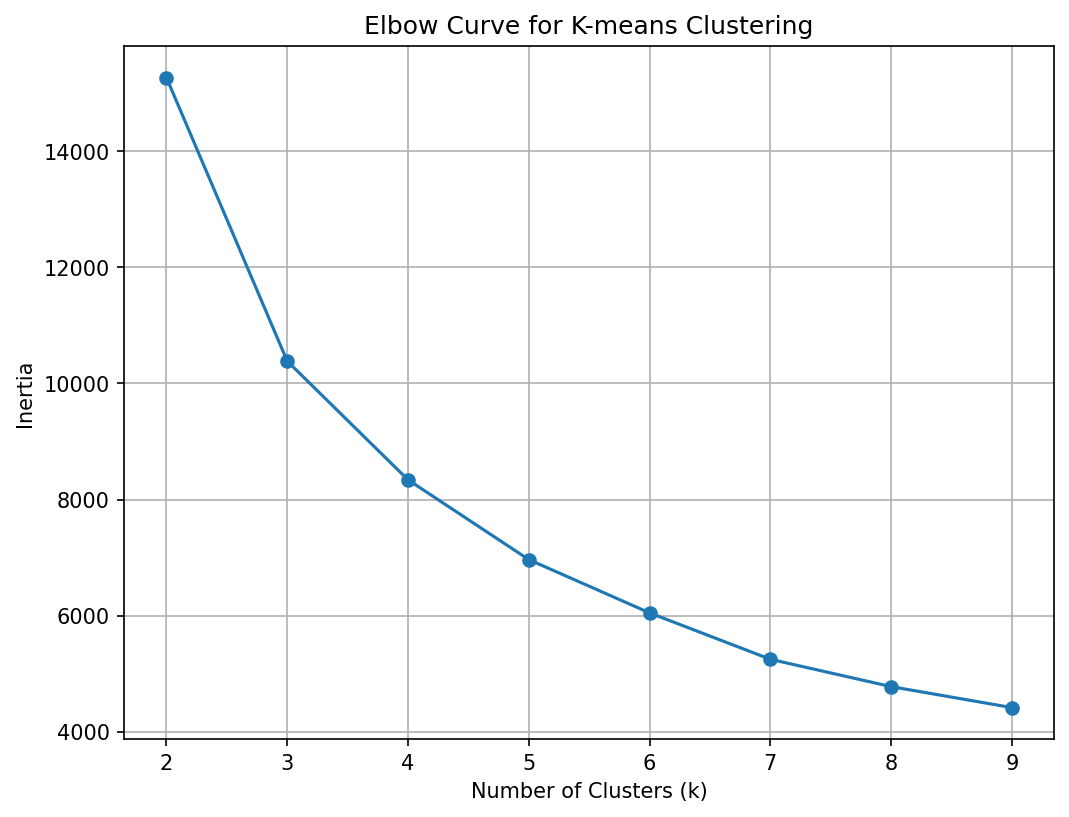

In [24]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia_a, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [25]:
# Perform K-means clustering with best K
best_kmeans_a = KMeans(n_clusters=4, n_init=20, random_state=42)
all_var['Cluster'] = best_kmeans_a.fit_predict(all_var_scaled)

In [26]:
# Group by cluster and calculate mean values
cluster_summary_a = all_var.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean'
}).reset_index()
print(cluster_summary_a)


   Cluster  recency_days  orders_last_12m  avg_order_value  \
0        0     77.627034         8.169078        59.582301   
1        1     89.677984         7.250000        73.983189   
2        2    551.739418         0.994709        29.932652   
3        3     80.581288         3.932515       203.395100   

   category_concentration  
0                0.142914  
1                0.327586  
2                0.188791  
3                0.175906  


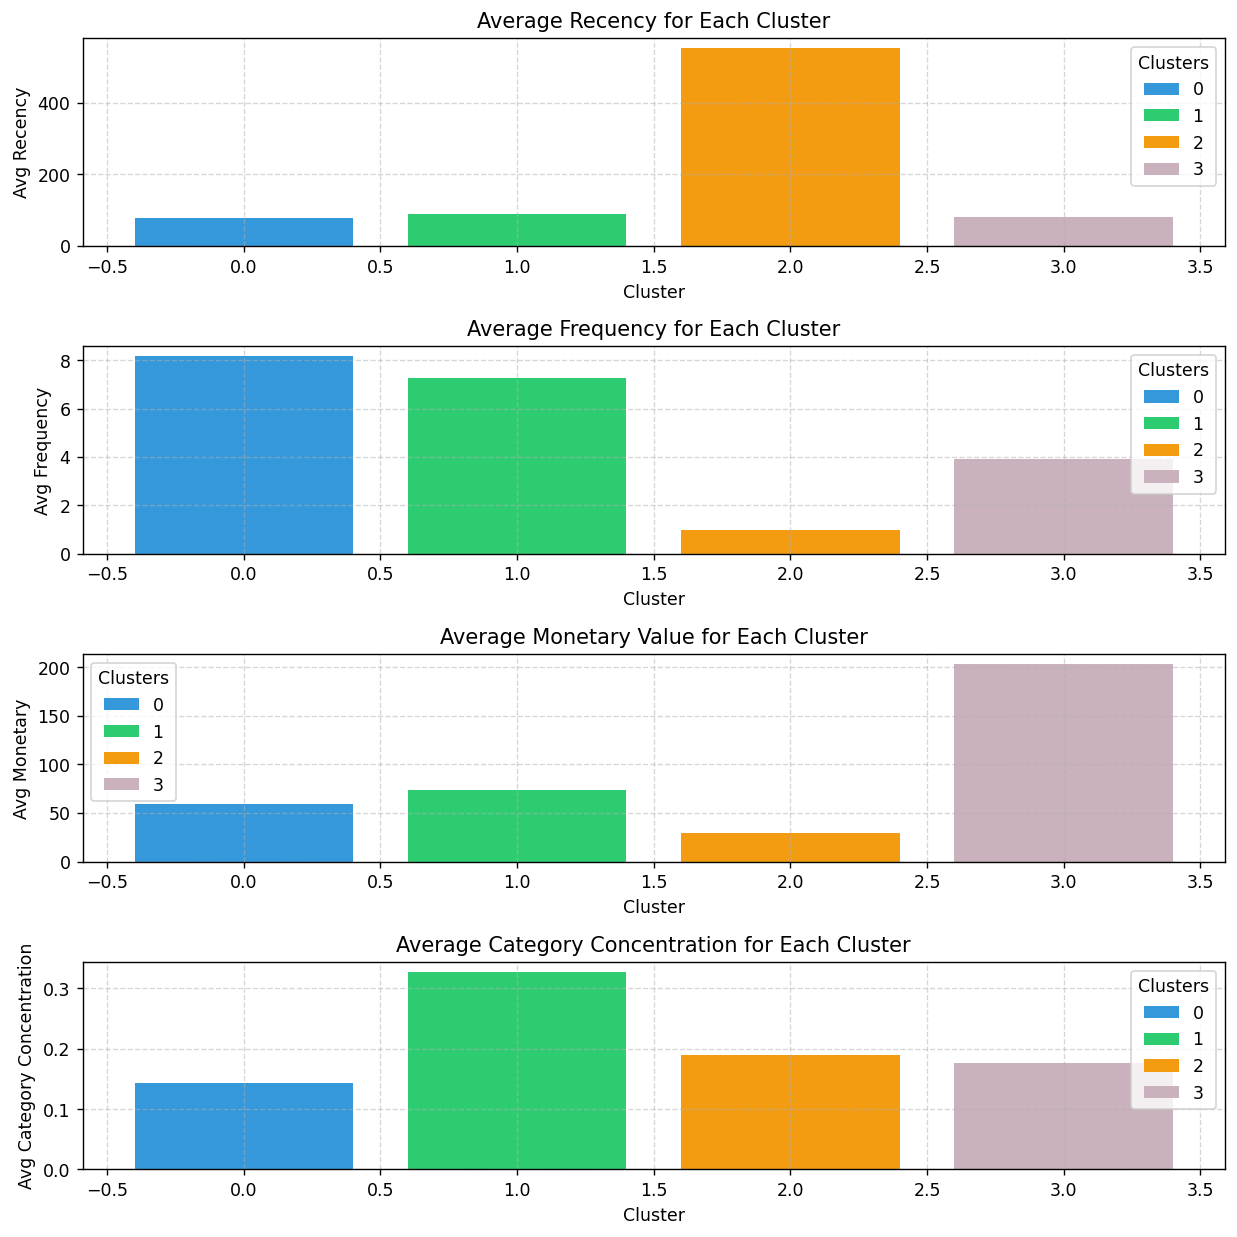

In [27]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 10),dpi=125)

# Plot Avg Recency
plt.subplot(4, 1, 1)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(4, 1, 2)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(4, 1, 3)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(4, 1, 4)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

plt.tight_layout()
plt.show()

Model 3 with engagement metrics

In [28]:
with_eng_var = df[['recency_days','orders_last_12m','avg_order_value','category_concentration','website_visits_30d','email_opens_90d']].copy()
with_eng_var.head()

,recency_days,orders_last_12m,avg_order_value,category_concentration,website_visits_30d,email_opens_90d
0,185,4,80.41,0.125281,6,2
1,146,5,171.52,0.227558,6,5
2,546,1,22.90,0.220894,1,7
3,37,8,38.67,0.038698,7,4
4,71,15,49.69,0.147430,13,5


Scaling Variables

In [29]:
with_eng_var_scaled = scaler.fit_transform(with_eng_var)
with_eng_var_scaled

array([[-0.06627777, -0.31706395, -0.07516376, -0.67988331, -0.10519462,
        -1.35310754],
       [-0.24214466, -0.07156341,  1.21966829,  0.36922992, -0.10519462,
        -0.00270081],
       [ 1.56161836, -1.05356556, -0.89248119,  0.30087219, -1.15399443,
         0.89757034],
       ...,
       [-0.47663386, -0.31706395, -0.15332836, -0.37045814,  0.10456534,
         0.89757034],
       [-0.46761504,  1.64694036, -0.72321932, -0.00813083,  0.94360519,
         1.79784149],
       [ 2.29214239, -1.05356556, -0.78901969, -0.93788856, -1.36375439,
         1.79784149]])

In [30]:
with_eng_var_scaled.mean(axis=0)

array([-5.92118946e-18, -2.25005200e-17,  3.96719694e-17, -1.77635684e-17,
       -2.13162821e-17, -8.76336041e-17])

In [31]:
with_eng_var_scaled.std(axis=0, ddof = 0)

array([1., 1., 1., 1., 1., 1.])

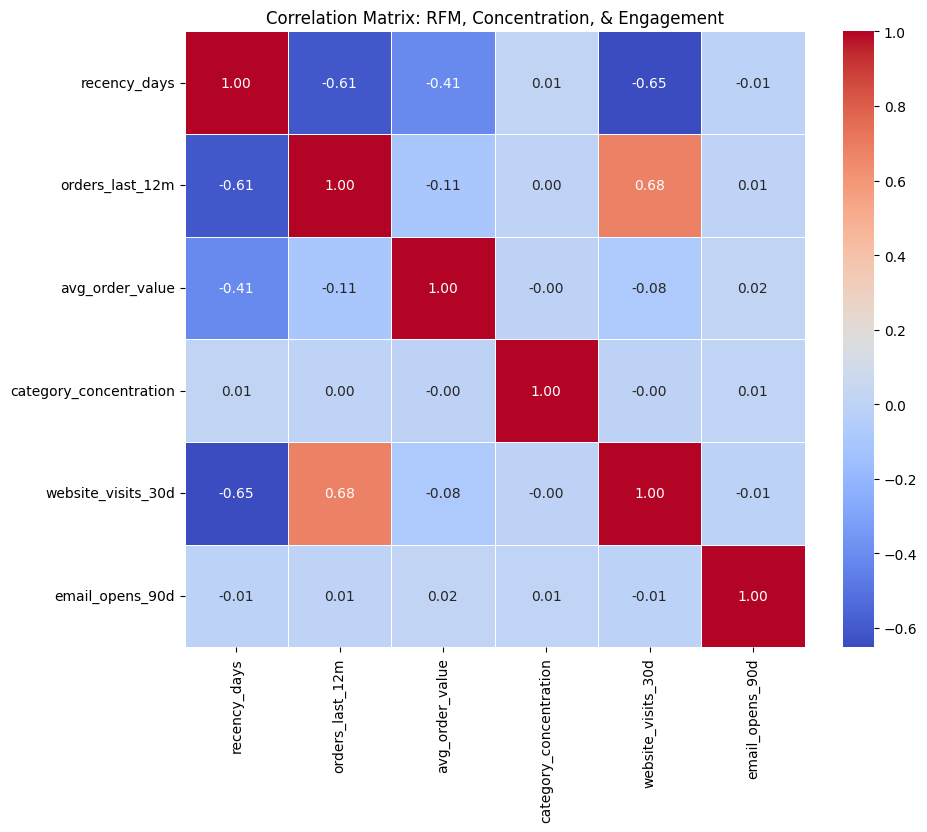

In [32]:
# 1. Convert the scaled array back into a DataFrame using original column names
corr_df3 = pd.DataFrame(with_eng_var_scaled, columns=with_eng_var.columns)

# 2. Calculate the correlation matrix
corr_matrix3 = corr_df3.corr()

# 3. Visualize the matrix using a heatmap
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix3, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: RFM, Concentration, & Engagement')
plt.show()

Calculating Inertia for K in (2 to 10)

In [33]:
inertia_b = []
for k in range(2,10):
  kmeans_b = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans_b.fit(with_eng_var_scaled)
  inertia_b.append(kmeans_b.inertia_)

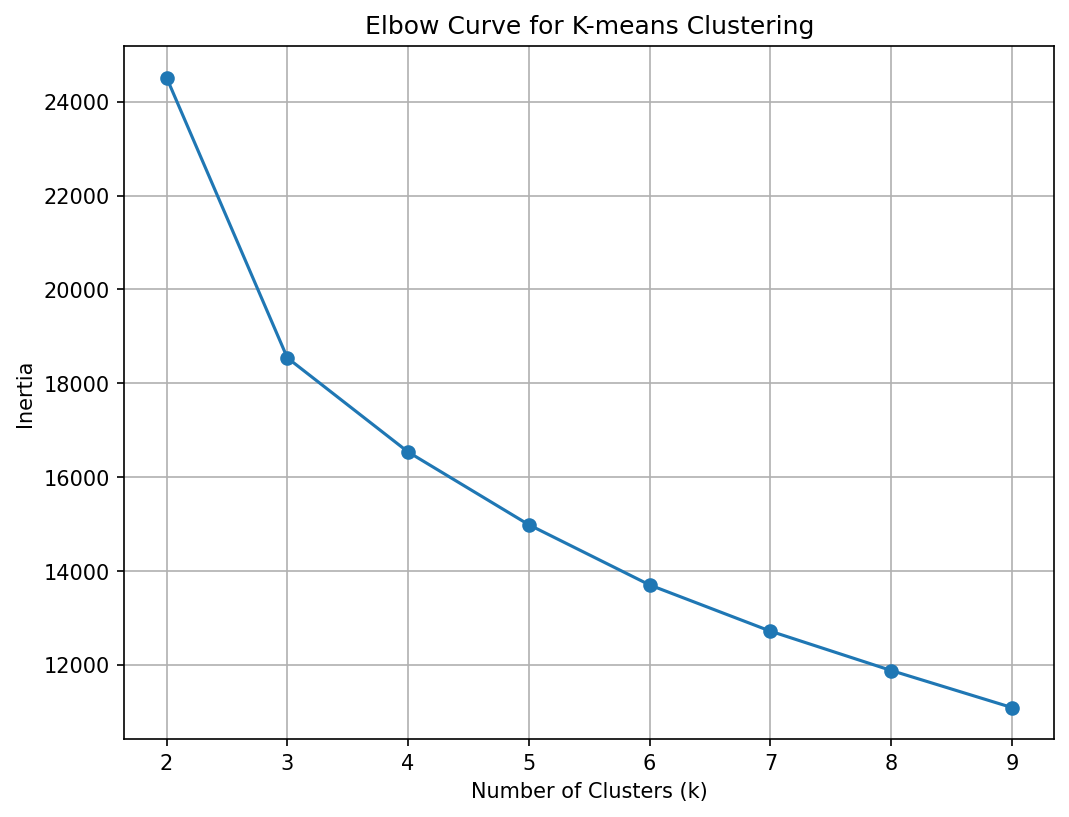

In [34]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia_b, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [35]:
# Perform K-means clustering with best K
best_kmeans_b = KMeans(n_clusters=3, n_init=20, random_state=42)
with_eng_var['Cluster'] = best_kmeans_b.fit_predict(with_eng_var_scaled)

In [36]:
# Group by cluster and calculate mean values
cluster_summary_b = with_eng_var.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean',
    'website_visits_30d': 'mean',
    'email_opens_90d': 'mean'
}).reset_index()
print(cluster_summary_b)

   Cluster  recency_days  orders_last_12m  avg_order_value  \
0        0     82.567725         3.980557       192.746073   
1        1    549.669271         0.998698        29.900768   
2        2     77.539199         8.241356        58.493091   

   category_concentration  website_visits_30d  email_opens_90d  
0                0.191330            5.009073         5.064161  
1                0.193404            0.998698         4.960938  
2                0.190716           10.183499         4.998973  


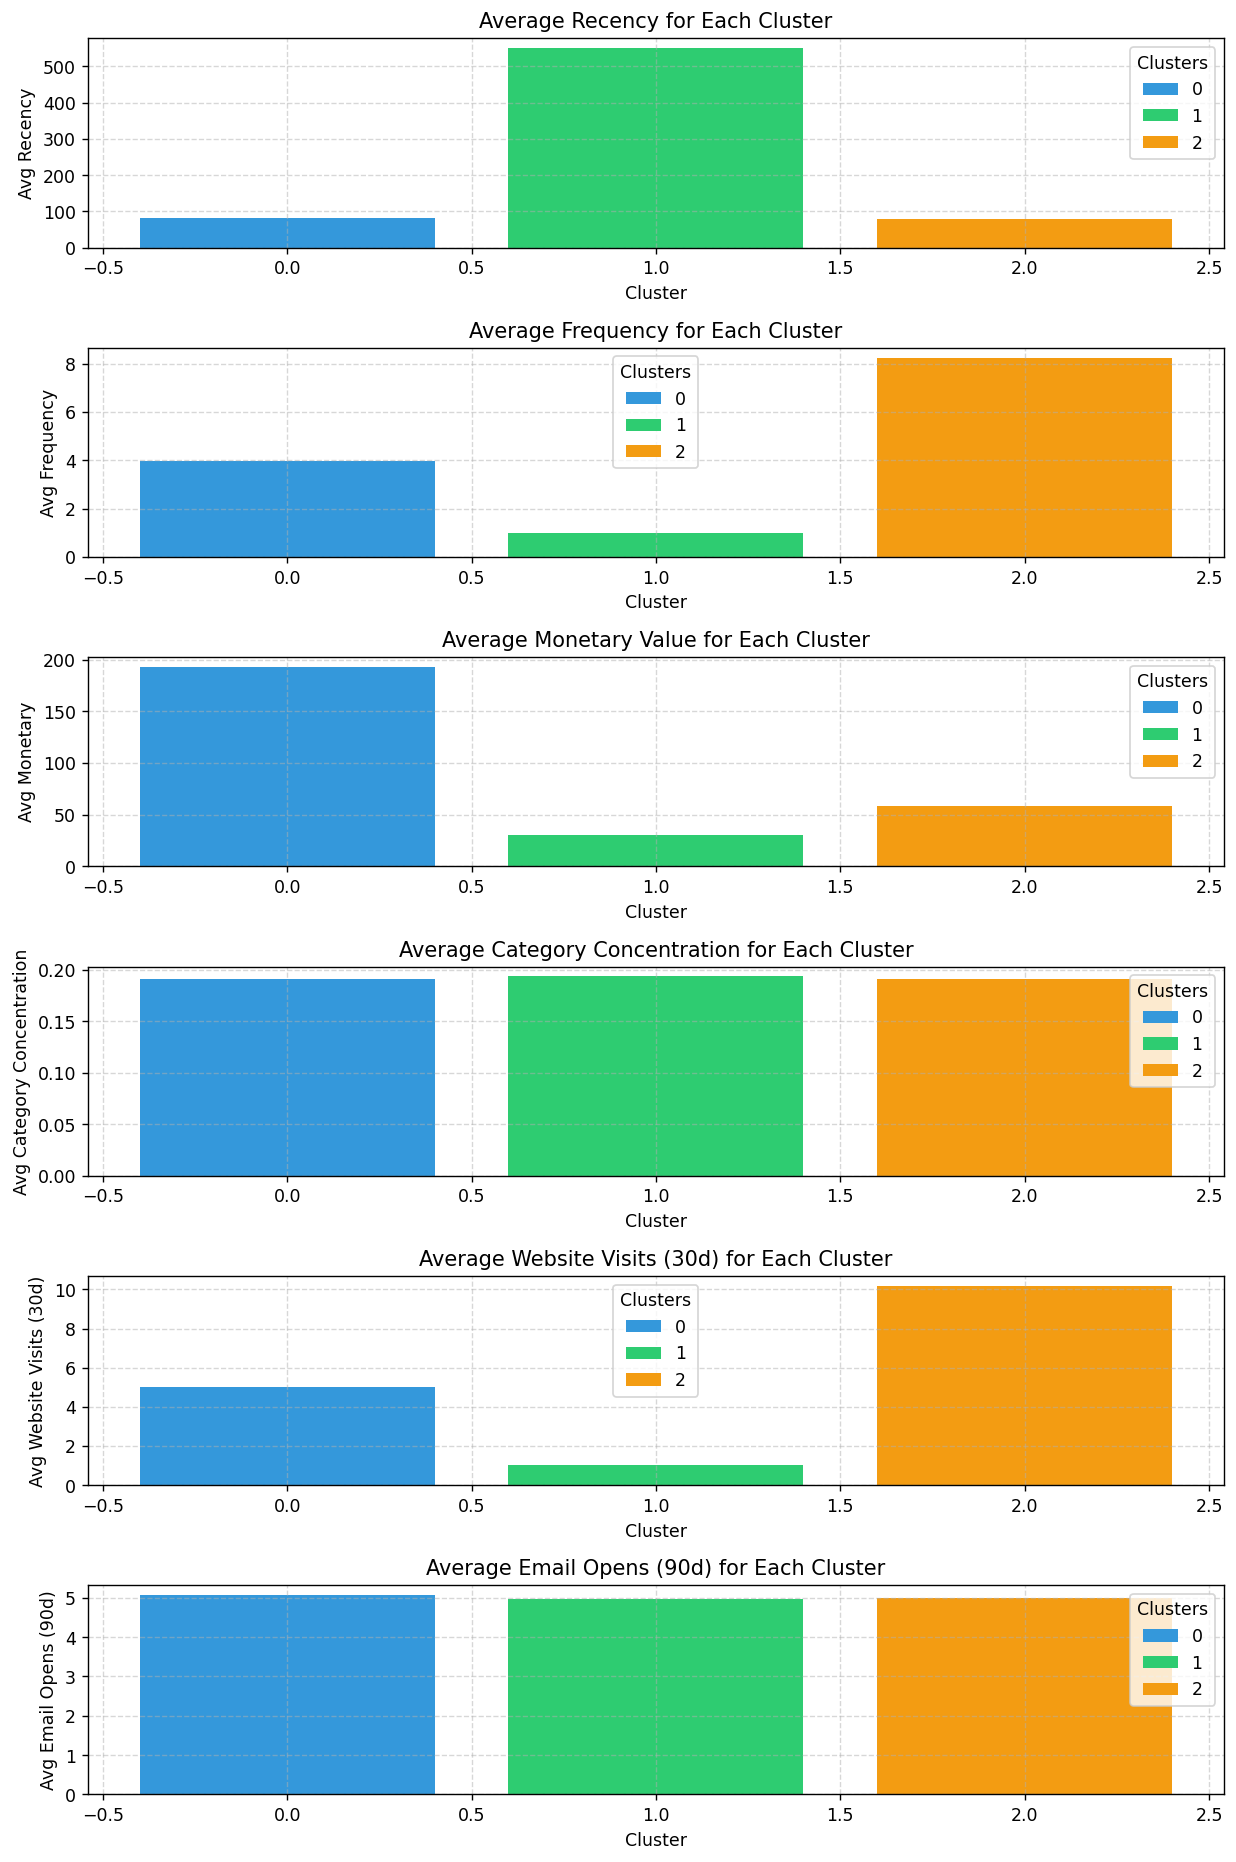

In [37]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 15),dpi=125) # Increased figure height for 6 subplots

# Plot Avg Recency
plt.subplot(6, 1, 1)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(6, 1, 2)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(6, 1, 3)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(6, 1, 4)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

# Plot Avg Website Visits
plt.subplot(6, 1, 5)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['website_visits_30d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Website Visits (30d)')
plt.title('Average Website Visits (30d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

# Plot Avg Email Opens
plt.subplot(6, 1, 6)
bars = plt.bar(cluster_summary_b.index, cluster_summary_b['email_opens_90d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Email Opens (90d)')
plt.title('Average Email Opens (90d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_b.index, title='Clusters')

plt.tight_layout()
plt.show()

In [38]:
# Perform K-means clustering with best K
best_kmeans_bb = KMeans(n_clusters=4, n_init=20, random_state=42)
with_eng_var['Cluster'] = best_kmeans_bb.fit_predict(with_eng_var_scaled)

In [39]:
# Group by cluster and calculate mean values
cluster_summary_bb = with_eng_var.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean',
    'website_visits_30d': 'mean',
    'email_opens_90d': 'mean'
}).reset_index()
print(cluster_summary_bb)

   Cluster  recency_days  orders_last_12m  avg_order_value  \
0        0    549.579427         0.997396        29.921055   
1        1     76.594360         8.261388        58.010873   
2        2     81.174004         3.965059       198.650559   
3        3     81.271657         7.829268        64.754710   

   category_concentration  website_visits_30d  email_opens_90d  
0                0.193340            1.000651         4.957031  
1                0.168701           10.461497         3.682213  
2                0.189855            4.939902         4.933613  
3                0.226774            9.345669         7.209420  


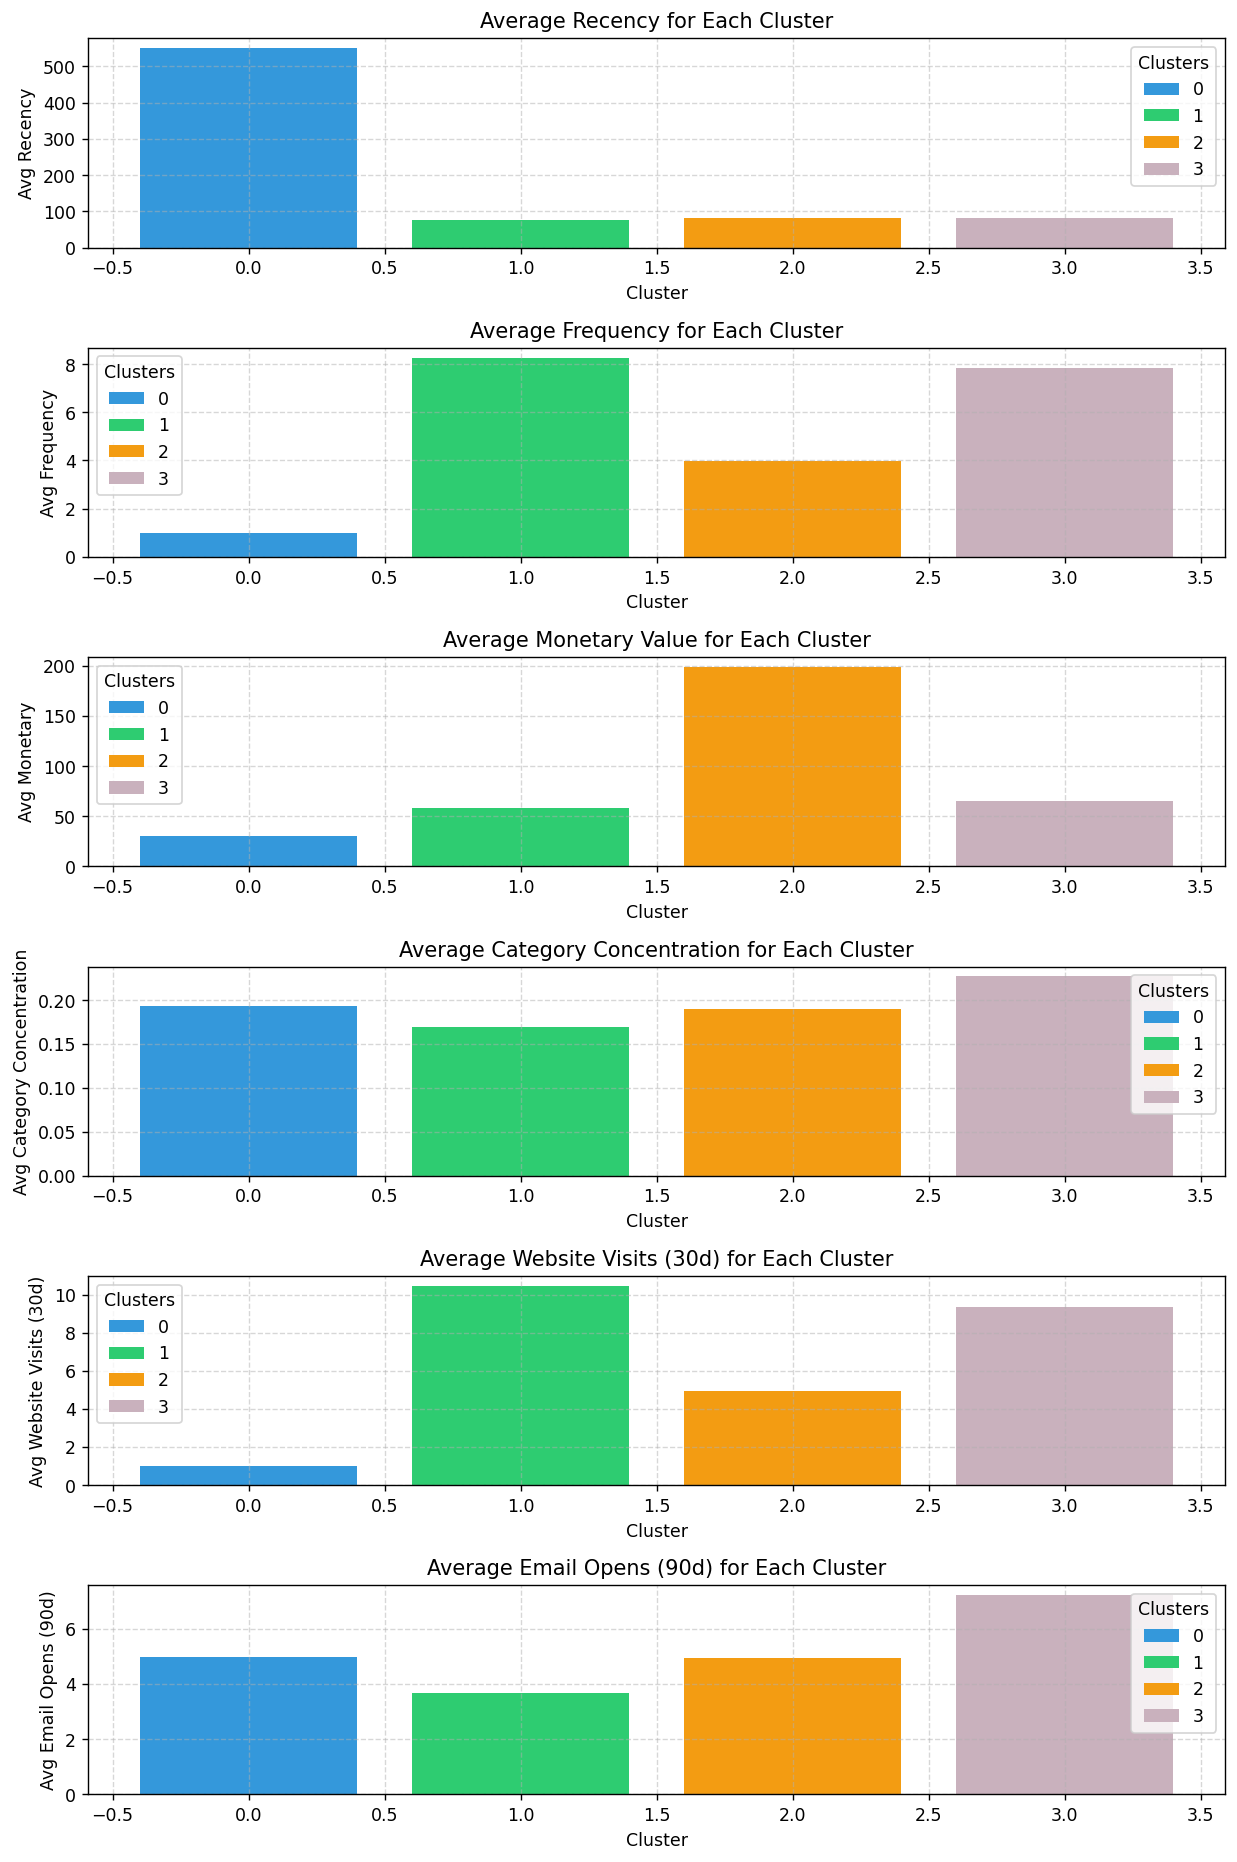

In [40]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 15),dpi=125) # Increased figure height for 6 subplots

# Plot Avg Recency
plt.subplot(6, 1, 1)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(6, 1, 2)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(6, 1, 3)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(6, 1, 4)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

# Plot Avg Website Visits
plt.subplot(6, 1, 5)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['website_visits_30d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Website Visits (30d)')
plt.title('Average Website Visits (30d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

# Plot Avg Email Opens
plt.subplot(6, 1, 6)
bars = plt.bar(cluster_summary_bb.index, cluster_summary_bb['email_opens_90d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Email Opens (90d)')
plt.title('Average Email Opens (90d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_bb.index, title='Clusters')

plt.tight_layout()
plt.show()

RFM + Category Concentration + Website visits

In [41]:
with_web = df[['recency_days','orders_last_12m','avg_order_value','category_concentration','website_visits_30d']].copy()
with_web.head()

,recency_days,orders_last_12m,avg_order_value,category_concentration,website_visits_30d
0,185,4,80.41,0.125281,6
1,146,5,171.52,0.227558,6
2,546,1,22.90,0.220894,1
3,37,8,38.67,0.038698,7
4,71,15,49.69,0.147430,13


In [42]:
with_web_scaled = scaler.fit_transform(with_web)
with_web_scaled

array([[-0.06627777, -0.31706395, -0.07516376, -0.67988331, -0.10519462],
       [-0.24214466, -0.07156341,  1.21966829,  0.36922992, -0.10519462],
       [ 1.56161836, -1.05356556, -0.89248119,  0.30087219, -1.15399443],
       ...,
       [-0.47663386, -0.31706395, -0.15332836, -0.37045814,  0.10456534],
       [-0.46761504,  1.64694036, -0.72321932, -0.00813083,  0.94360519],
       [ 2.29214239, -1.05356556, -0.78901969, -0.93788856, -1.36375439]])

In [46]:
print(with_web_scaled.mean(axis=0))
print(with_web_scaled.std(axis=0,ddof=0))

[-5.92118946e-18 -2.25005200e-17  3.96719694e-17 -1.77635684e-17
 -2.13162821e-17]
[1. 1. 1. 1. 1.]


In [47]:
inertia_c = []
for k in range(2,10):
  kmeans_c = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans_c.fit(with_web_scaled)
  inertia_c.append(kmeans_c.inertia_)

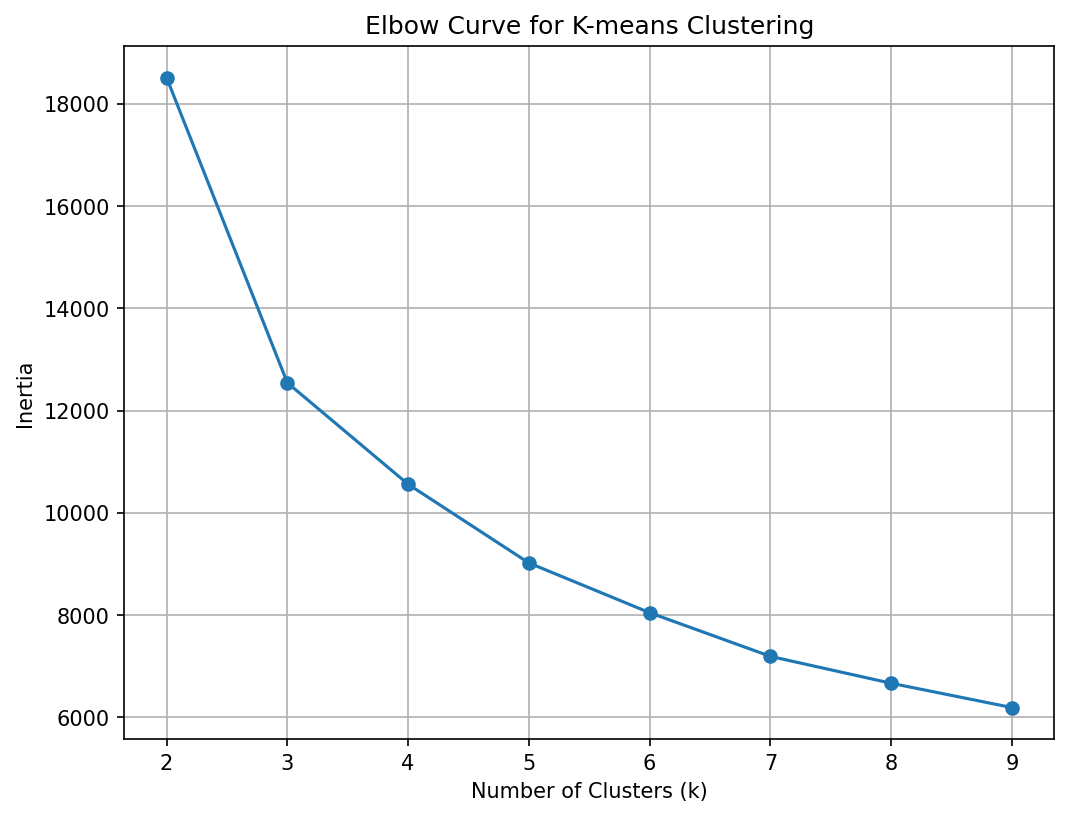

In [48]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia_c, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [49]:
# Perform K-means clustering with best K
best_kmeans_c = KMeans(n_clusters=3, n_init=20, random_state=42)
with_web['Cluster'] = best_kmeans_c.fit_predict(with_web_scaled)

In [50]:
# Group by cluster and calculate mean values
cluster_summary_c = with_web.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean',
    'website_visits_30d': 'mean'
}).reset_index()
print(cluster_summary_c)

   Cluster  recency_days  orders_last_12m  avg_order_value  \
0        0    549.669271         0.998698        29.900768   
1        1     77.446998         8.250429        58.429293   
2        2     82.721756         3.979987       192.346107   

   category_concentration  website_visits_30d  
0                0.193404            0.998698  
1                0.190814           10.192453  
2                0.191144            5.012266  


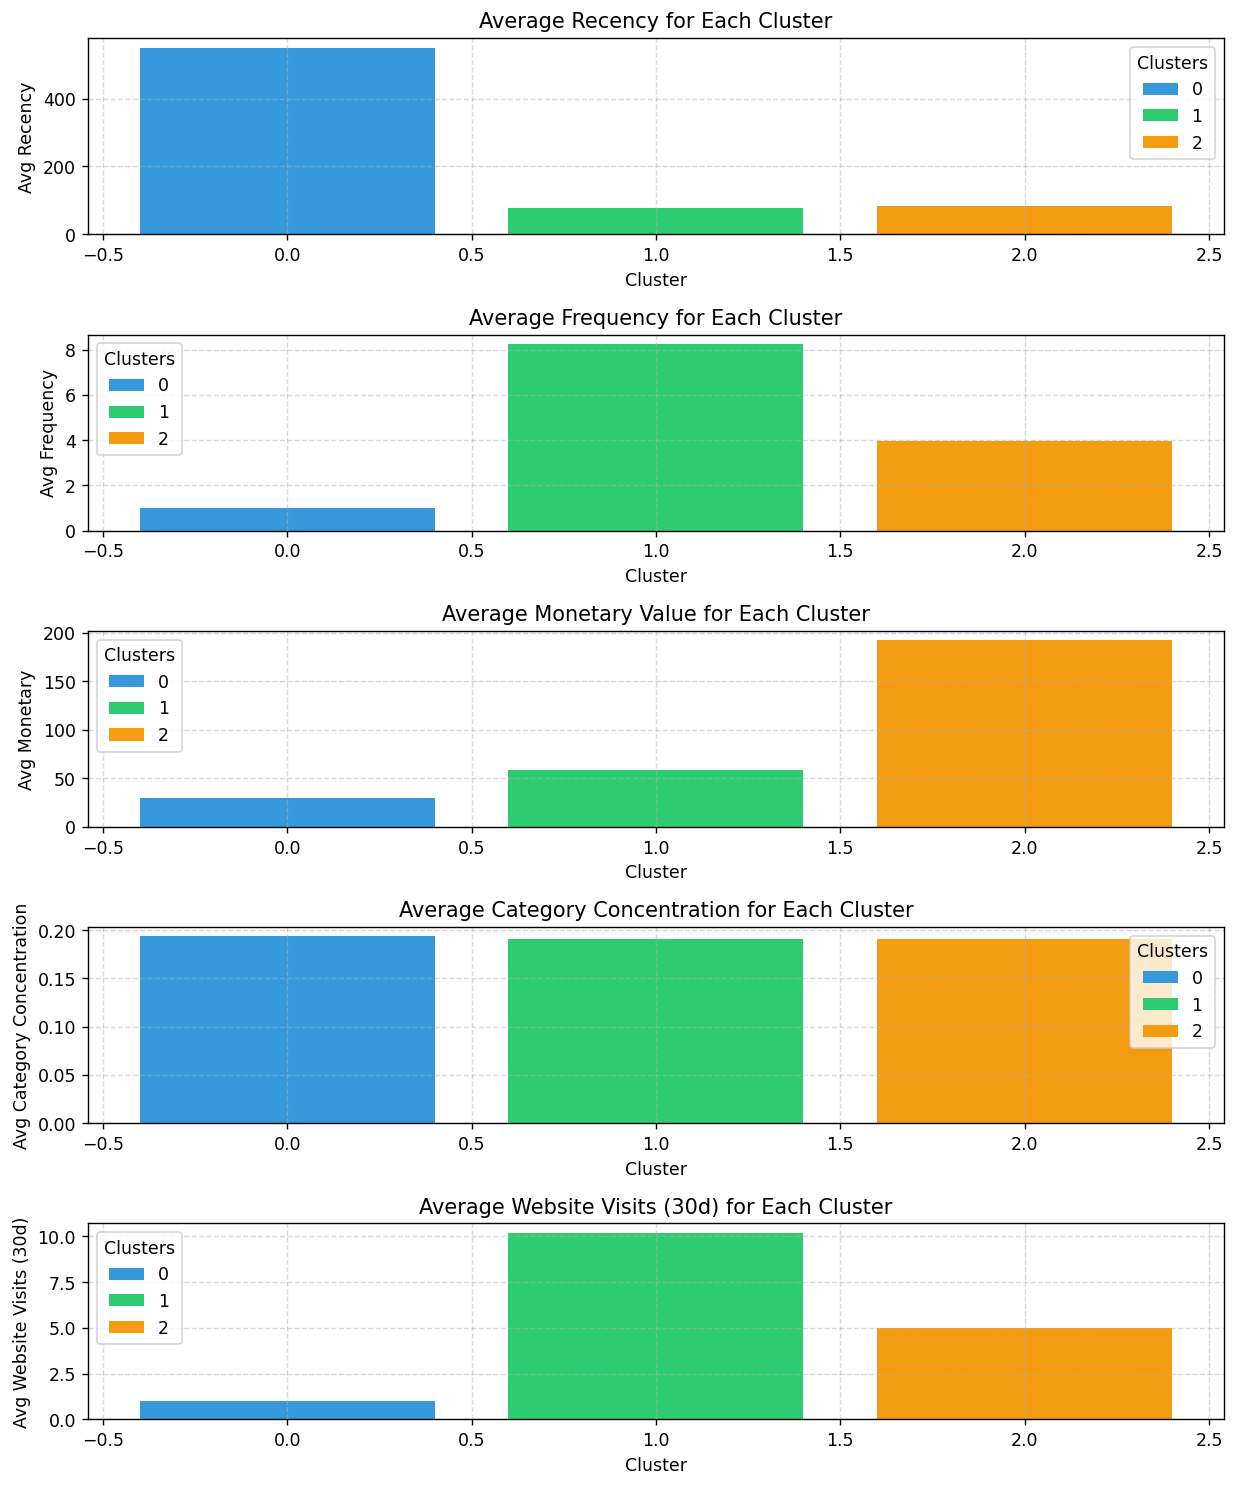

In [51]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 12),dpi=125) # Adjusted figure height for 5 subplots

# Plot Avg Recency
plt.subplot(5, 1, 1)
bars = plt.bar(cluster_summary_c.index, cluster_summary_c['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_c.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(5, 1, 2)
bars = plt.bar(cluster_summary_c.index, cluster_summary_c['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_c.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(5, 1, 3)
bars = plt.bar(cluster_summary_c.index, cluster_summary_c['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_c.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(5, 1, 4)
bars = plt.bar(cluster_summary_c.index, cluster_summary_c['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_c.index, title='Clusters')

# Plot Avg Website Visits
plt.subplot(5, 1, 5)
bars = plt.bar(cluster_summary_c.index, cluster_summary_c['website_visits_30d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Website Visits (30d)')
plt.title('Average Website Visits (30d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_c.index, title='Clusters')

plt.tight_layout()
plt.show()

In [54]:
# Perform K-means clustering with best K
best_kmeans_cb = KMeans(n_clusters=4, n_init=20, random_state=42)
with_web['Cluster'] = best_kmeans_cb.fit_predict(with_web_scaled)

In [55]:
# Group by cluster and calculate mean values
cluster_summary_cb = with_web.groupby('Cluster').agg({
    'recency_days': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean',
    'website_visits_30d': 'mean'
}).reset_index()
print(cluster_summary_cb)

   Cluster  recency_days  orders_last_12m  avg_order_value  \
0        0    549.669271         0.998698        29.900768   
1        1     54.755690        11.030349        43.414977   
2        2     79.404100         4.032211       204.427182   
3        3     97.337079         5.712921        74.043281   

   category_concentration  website_visits_30d  
0                0.193404            0.998698  
1                0.201092           12.352049  
2                0.193488            4.931186  
3                0.181439            8.123034  


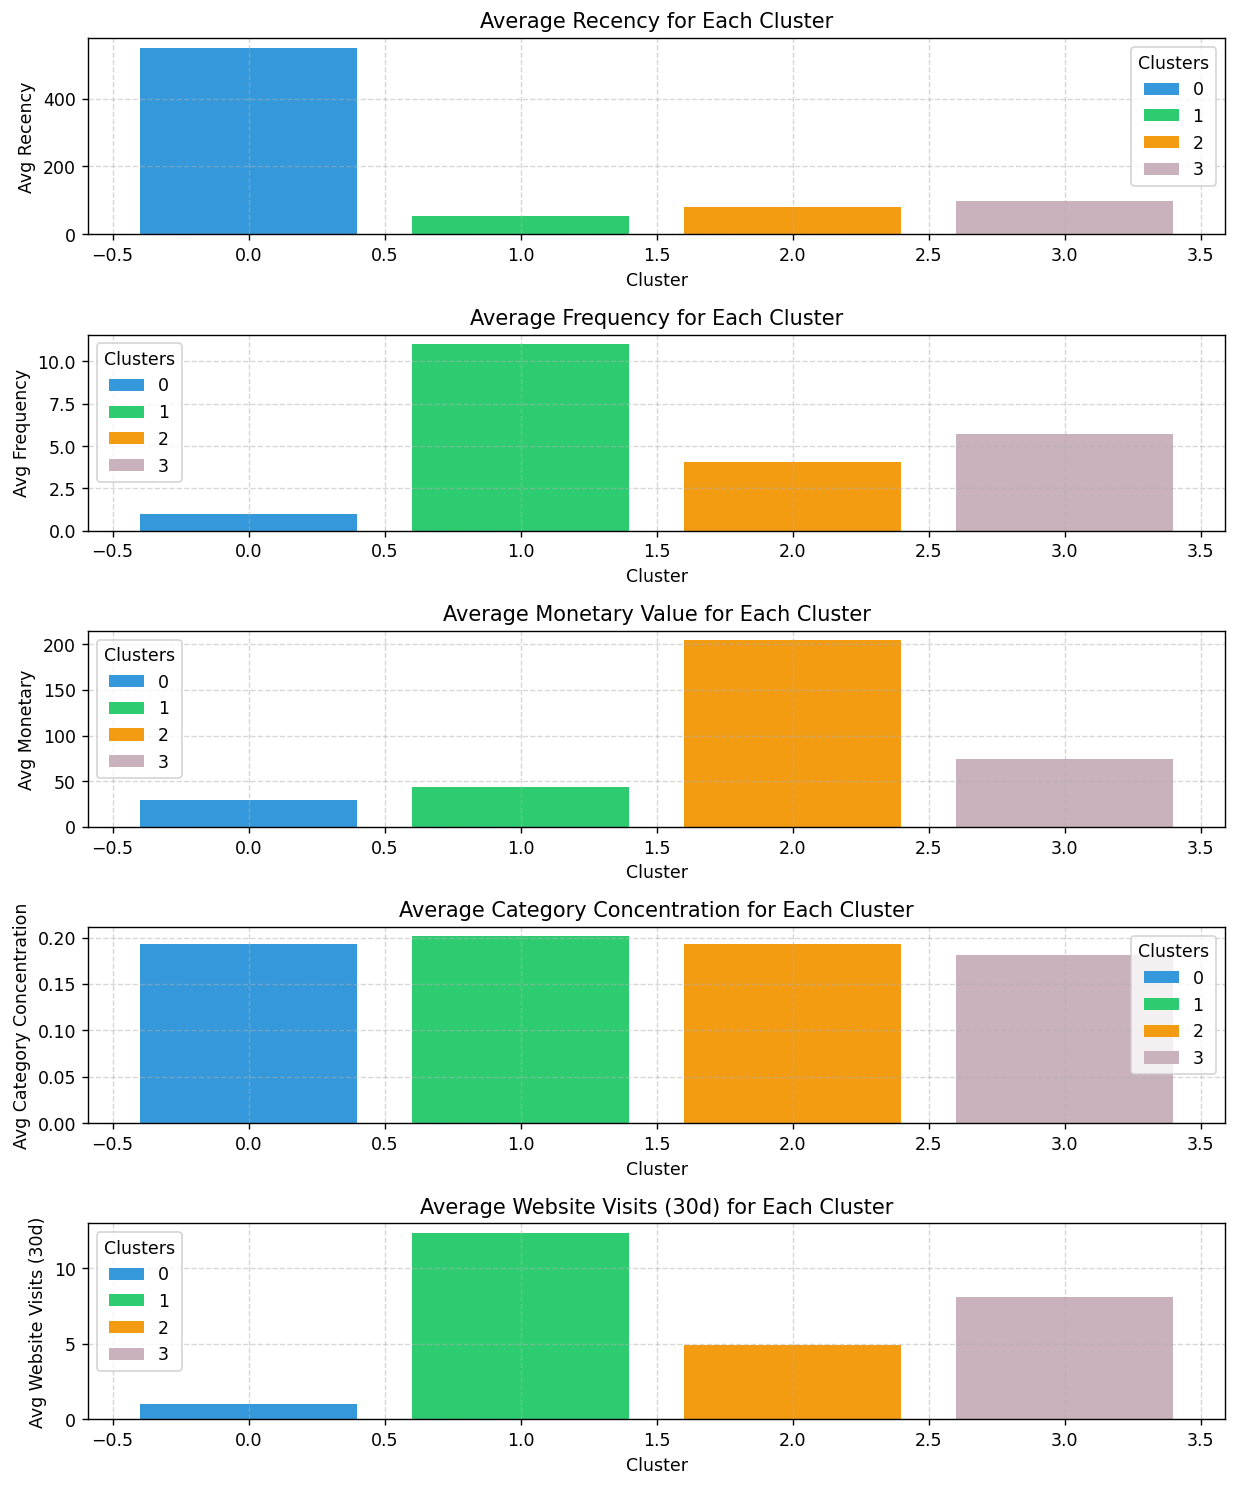

In [56]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 12),dpi=125) # Adjusted figure height for 5 subplots

# Plot Avg Recency
plt.subplot(5, 1, 1)
bars = plt.bar(cluster_summary_cb.index, cluster_summary_cb['recency_days'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_cb.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(5, 1, 2)
bars = plt.bar(cluster_summary_cb.index, cluster_summary_cb['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_cb.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(5, 1, 3)
bars = plt.bar(cluster_summary_cb.index, cluster_summary_cb['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_cb.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(5, 1, 4)
bars = plt.bar(cluster_summary_cb.index, cluster_summary_cb['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_cb.index, title='Clusters')

# Plot Avg Website Visits
plt.subplot(5, 1, 5)
bars = plt.bar(cluster_summary_cb.index, cluster_summary_cb['website_visits_30d'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Website Visits (30d)')
plt.title('Average Website Visits (30d) for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_cb.index, title='Clusters')

plt.tight_layout()
plt.show()